# Renko prototype

Prototyping the transform-then-render split from [notes/view-transforms.md](../../notes/view-transforms.md): `calc_renko` turns prices into a brick frame (one row per brick, completion-dated), and the `Renko` primitive binds that transform to the chart view via `Chart.get_view(transform=...)` before delegating rendering to `Candlesticks` — the target API end to end:

```python
Chart(prices, max_bars=120).plot(Renko(brick_size=5.0))
```

The calc runs at numpy level. `utils.wrap_result` assumes row-aligned results (the pandas branch reuses the *source* index), so a domain transform needs a date-carrying wrap variant — prototyped locally here, a candidate `wrap_result` extension when this promotes to src.


In [1]:
import sys
import numpy as np

from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.utils import col_to_numpy, detect_backend
from mplchart.primitives import Volume
from mplchart.primitives.candlesticks import Candlesticks

prices = sample_prices(freq="daily")
prices.tail()


,open,high,low,close,volume
date,,,,,
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


## Helpers

`get_dates` reads the datetime domain from either backend; `wrap_bricks` is the domain-transform variant of `wrap_result` — same `sys.modules` trick, but the result carries its own dates instead of the source index.


In [2]:
def get_dates(prices):
    """datetime64 array of the prices dates — index (pandas) or first date column (polars)"""
    if detect_backend(prices) == "pandas":
        return prices.index.to_numpy()
    pl = sys.modules["polars"]
    for name, dtype in prices.schema.items():
        if dtype == pl.Date or dtype == pl.Datetime:
            return prices[name].to_numpy()
    raise ValueError("No Date or Datetime column found")


def wrap_bricks(data, dates, source):
    """wrap brick arrays into the source backend — like utils.wrap_result,
    but the result has its own dates (domain transform, not row-aligned)"""
    if detect_backend(source) == "polars":
        pl = sys.modules["polars"]
        return pl.DataFrame({"date": dates, **data})
    pd = sys.modules["pandas"]
    return pd.DataFrame(data, index=pd.DatetimeIndex(dates, name="date"))


## calc_renko

Close-based bricks with the classic 2-brick reversal, expressed as one symmetric rule pair over the last brick's `top`/`bottom`: an up brick lays when close reaches `top + size`, a down brick when close reaches `bottom - size`. After any brick `top - bottom == size`, so a reversal implicitly needs two sizes from the last extreme. The seed snaps the first close to the brick grid with `top == bottom` so the first brick is symmetric in both directions.

Default brick size is the mean true range of the data (mplfinance-style ATR default). Volume accumulated since the previous brick is shared evenly across the bricks a bar completes.


In [3]:
def calc_renko(prices, brick_size=None):
    """Renko bricks from a prices frame — one row per brick, completion-dated.

    Returns an OHLCV frame in the source backend: open/close directional,
    high/low the brick extremes, volume summed since the previous brick.
    """
    dates = get_dates(prices)
    high = col_to_numpy(prices, "high")
    low = col_to_numpy(prices, "low")
    close = col_to_numpy(prices, "close")
    volume = col_to_numpy(prices, "volume")

    if brick_size is None:
        prev = np.concatenate((close[:1], close[:-1]))
        tr = np.maximum(high - low, np.maximum(np.abs(high - prev), np.abs(low - prev)))
        brick_size = float(np.nanmean(tr))

    size = float(brick_size)

    # seed: first close snapped to the brick grid, zero-height anchor
    top = bottom = round(close[0] / size) * size

    idx, opens, closes, vols = [], [], [], []
    accum = float(volume[0])

    for i in range(1, len(close)):
        accum += float(volume[i])
        emitted = 0
        while close[i] >= top + size:  # up brick
            opens.append(top)
            closes.append(top + size)
            bottom, top = top, top + size
            idx.append(i)
            emitted += 1
        while close[i] <= bottom - size:  # down brick
            opens.append(bottom)
            closes.append(bottom - size)
            top, bottom = bottom, bottom - size
            idx.append(i)
            emitted += 1
        if emitted:
            # volume since the previous brick, shared evenly across the
            # bricks this bar completed
            vols.extend([accum / emitted] * emitted)
            accum = 0.0

    opens = np.array(opens, dtype=float)
    closes = np.array(closes, dtype=float)
    idx = np.array(idx, dtype=int)

    # nudge same-bar bricks +1ns each: pandas date-aligned slicing goes
    # cartesian on duplicate dates (see Findings) — unique timestamps keep
    # the alignment 1:1; the offset is invisible in date labels
    rank = np.arange(len(idx)) - np.searchsorted(idx, idx)
    brick_dates = dates[idx].astype("datetime64[ns]") + rank * np.timedelta64(1, "ns")

    data = dict(
        open=opens,
        high=np.maximum(opens, closes),
        low=np.minimum(opens, closes),
        close=closes,
        volume=np.array(vols, dtype=float),
    )
    return wrap_bricks(data, brick_dates, prices)


In [4]:
bricks = calc_renko(prices, brick_size=5.0)
print(f"{len(prices)} bars -> {len(bricks)} bricks")
print(f"{int(bricks.index.normalize().duplicated().sum())} bricks share a completion day (multi-brick bars)")
bricks.tail()


11325 bars -> 205 bricks
17 bricks share a completion day (multi-brick bars)


,open,high,low,close,volume
date,,,,,
2025-09-22 00:00:00.000000001,250.0,255.0,250.0,255.0,52758700.0
2025-10-20 00:00:00.000000000,255.0,260.0,255.0,260.0,922548400.0
2025-10-27 00:00:00.000000000,260.0,265.0,260.0,265.0,207608000.0
2025-10-30 00:00:00.000000000,265.0,270.0,265.0,270.0,162508000.0
2025-11-11 00:00:00.000000000,270.0,275.0,270.0,275.0,416271700.0


## Renko primitive

Bricks are candle bodies with no wicks (high/low coincide with the body), so rendering is just `Candlesticks` with touching full-width bodies. The primitive carries the transform params and binds the transform as its first act — `chart.get_view(transform=self.transform)` — then delegates to the parent. The transform is a bound method (equivalent to `functools.partial(calc_renko, brick_size=...)`, but overridable and import-free). Renko must be the first view-toucher on the chart; a later transform raises.


In [5]:
class Renko(Candlesticks):
    """Renko bricks — candlesticks with touching, full-width bodies.

    Binds the renko transform to the chart view (must be the first
    view-toucher) and delegates rendering to Candlesticks.
    """

    def __init__(self, brick_size=None, *, label="Renko", width=1.0, alpha=None,
                 colorup=None, colordn=None):
        super().__init__(label=label, width=width, alpha=alpha,
                         colorup=colorup, colordn=colordn)
        self.brick_size = brick_size

    def transform(self, prices):
        return calc_renko(prices, brick_size=self.brick_size)

    def apply_to_chart(self, chart):
        chart.get_view(transform=self.transform)
        super().apply_to_chart(chart)


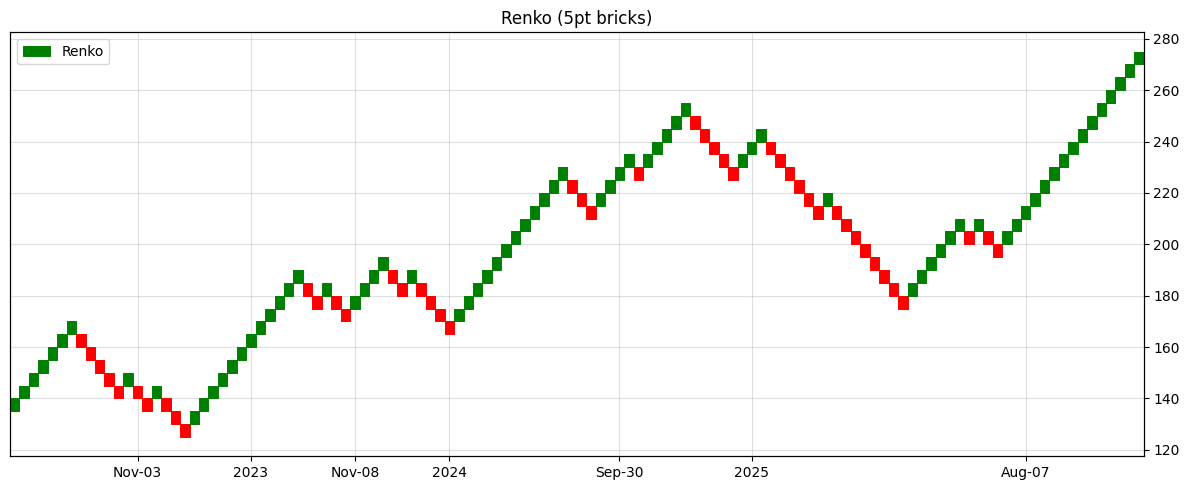

In [6]:
Chart(prices, title="Renko (5pt bricks)", max_bars=120, figsize=(12, 5)).plot(
    Renko(brick_size=5.0, colorup="green", colordn="red")
).show()


No transform by hand — the primitive bound it. `max_bars=120` counts *bricks*, and the dateaxis labels the bricks with their (non-uniform) completion dates.

## Composability

Renko binds the view first, so the rest of the plot list computes in brick space — `SMA(20)` is an SMA of *brick closes*, `Volume` shows per-brick volume.


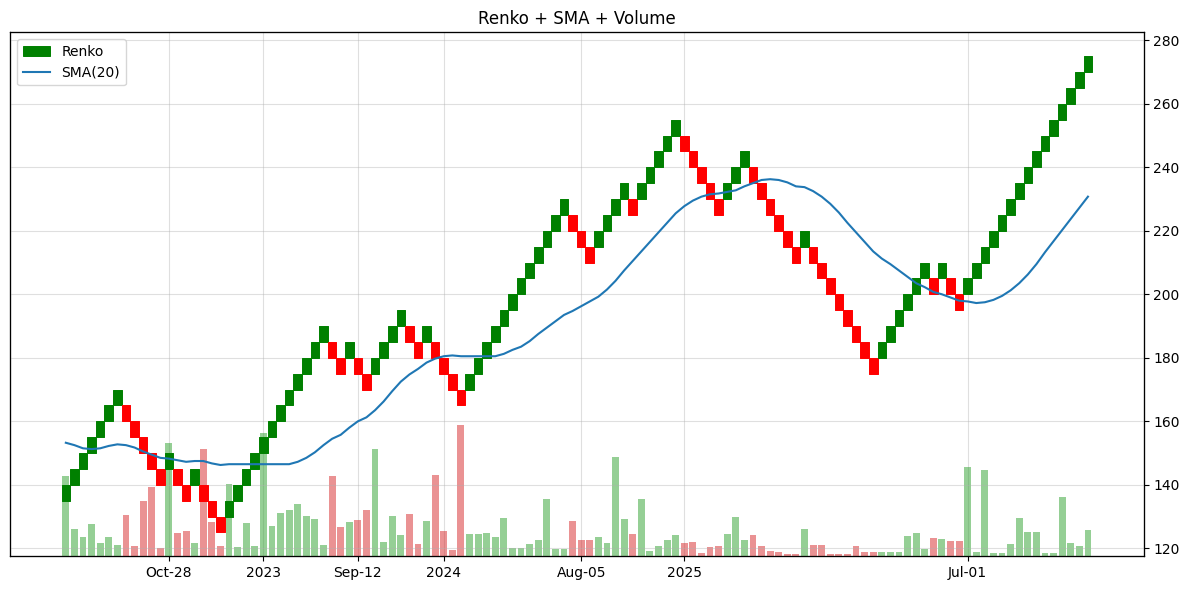

In [7]:
from mplchart.indicators import SMA

Chart(prices, title="Renko + SMA + Volume", max_bars=120, figsize=(12, 6)).plot(
    [Renko(brick_size=5.0, colorup="green", colordn="red"), SMA(20), Volume()]
).show()


## Auto brick size

`brick_size=None` defaults to the mean true range of the data.


auto brick size: 0.638 -> 4149 bricks


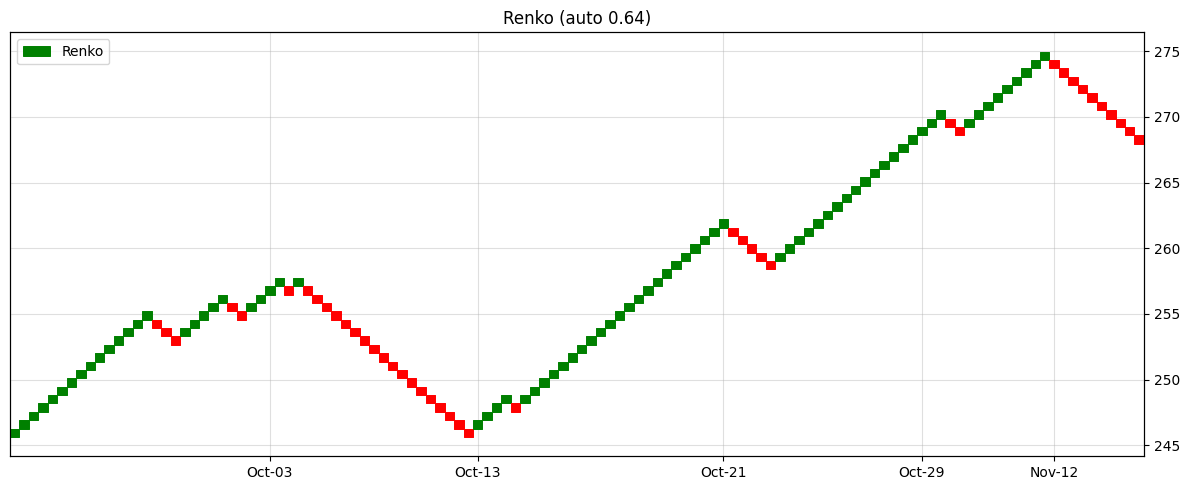

In [8]:
auto = calc_renko(prices)
auto_size = float(auto["high"].to_numpy()[0] - auto["low"].to_numpy()[0])
print(f"auto brick size: {auto_size:.3f} -> {len(auto)} bricks")

Chart(prices, title=f"Renko (auto {auto_size:.2f})", max_bars=120, figsize=(12, 5)).plot(
    Renko(colorup="green", colordn="red")
).show()


## Polars backend

Same primitive, polars prices — the transform runs in the polars backend end to end.


In [9]:
pl_prices = sample_prices(freq="daily", backend="polars")
calc_renko(pl_prices, brick_size=5.0).tail()


date,open,high,low,close,volume
datetime[ns],f64,f64,f64,f64,f64
2025-09-22 00:00:00.000000001,250.0,255.0,250.0,255.0,5.27587e7
2025-10-20 00:00:00,255.0,260.0,255.0,260.0,9.225484e8
2025-10-27 00:00:00,260.0,265.0,260.0,265.0,2.07608e8
2025-10-30 00:00:00,265.0,270.0,265.0,270.0,1.62508e8
2025-11-11 00:00:00,270.0,275.0,270.0,275.0,4.162717e8


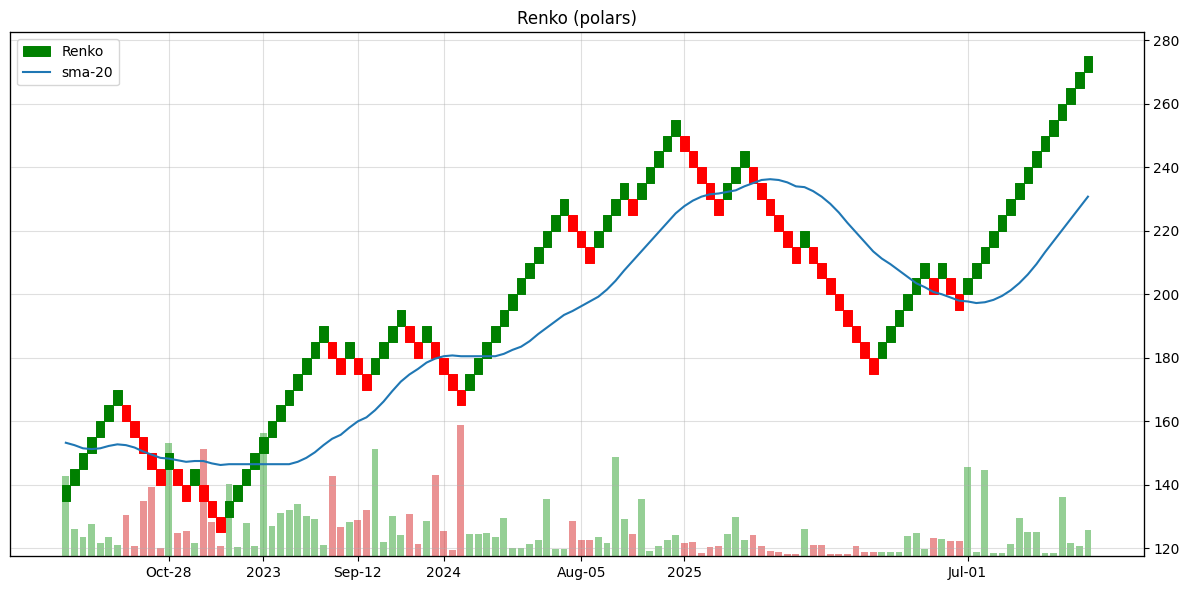

In [10]:
from mplchart.expressions import SMA as SMAX

Chart(pl_prices, title="Renko (polars)", max_bars=120, figsize=(12, 6)).plot(
    [Renko(brick_size=5.0, colorup="green", colordn="red"), SMAX(20), Volume()]
).show()


## Findings

- Target API achieved end to end: `Chart(prices).plot(Renko(brick_size=5.0))` — the primitive binds the transform via `chart.get_view(transform=...)` and must be the first view-toucher (anything plotted before it fixes the untransformed view; a later transform raises).
- The transform is passed as a bound method on the primitive — `functools.partial(calc_renko, brick_size=...)` would work identically; the method form is overridable and carries no extra state.
- The brick frame works as chart prices in both backends with zero further Chart changes — the rownum x-axis carries the domain transform.
- Duplicate completion dates break the pandas path: `PandasDataView.slice` aligns the windowed xloc against the full frame *by date*, and the inner join goes cartesian on duplicate labels (windowed rows multiply; duplicate x-values then collapse the body width to zero via `nanmin(diff)`). Polars is positional and unaffected. Workaround here: +1ns nudge per same-bar brick. Candidate real fix in src: a positional fast path in `slice` when `data is view.prices`.
- Windowing semantics confirmed: `start`/`end`/`max_bars` operate in brick space.
- Volume attribution: volume accumulated since the previous brick is shared evenly across the bricks a bar completes — totals conserved, no zero-volume sibling bricks. (PnF differs: per-bar rate; see pnf-proto.)
- The 2-brick reversal is implicit in the symmetric top/bottom rule; a configurable `reversal=` needs explicit trend tracking — deferred.
- Promotion path per [notes/view-transforms.md](../../notes/view-transforms.md): `calc_renko` + `Renko` into src and `wrap_result(dates=...)`; the phase-2 plumbing (`Chart.get_view(transform=...)`, lazy + cached, raw_dates guarded) is already in src.
